# r2=0.20, eps=0 haploblock validation

**The question.** At r2=0.10 (corrected), blocks are ~1.3Mb and K_b≈231 — almost
no two of the 231 accessions are k-mer-identical over that length, so exact
identity merges nobody and the reframe is a no-op. r2=0.20 gives **smaller
blocks** (110 on Chr1). Two ways K_b could drop below 231 there:

- **REAL IBD collapse (what we want):** founders that genuinely share a
  haplotype over the shorter region are k-mer-identical there → fewer distinct
  things, *with plenty of k-mers still present*. Real resolution gain.
- **STARVATION (what we don't):** the block simply has too few k-mers to tell
  founders apart. K_b drops for lack of signal, not lack of real difference.

This notebook uses the **corrected** per-k-mer→block assignment (via `bubble_id`)
and adds a K_b-vs-n_kmers diagnostic to tell these two apart. Chr1, 110 blocks,
g0-231 equimolar simulation (truth = 1/231).

## Acronyms

| Term | Meaning |
|---|---|
| **K_b** | Distinct exact-identity haploblocks in a block (real number of identifiable things vs. 231). |
| **n_kmers** | K-mers assigned to a block (its signal budget). Starvation ≈ few k-mers. |
| **TVD** | `0.5*sum|est-true|` between estimated & equimolar-truth haploblock freqs. Lower = better. |
| **production / old global** | All 231 founders scored separately vs 1/231 — no collapse. |
| **real collapse** | K_b<231 in a block that STILL has many k-mers (say >10k) — genuine IBD sharing. |
| **starvation** | K_b<231 only because the block has few k-mers. |


In [1]:

import numpy as np, scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "/global/scratch/users/tbellg/kmate"
OUT = f"{ROOT}/analysis/grenenet_gea/hap_blocks/bench_g0_231"
KMPRE = f"{ROOT}/benchmarks/p231/data/kmer_pa_p231_filt2inv/kmer_pa_Chr1"
F = 231
KMER_FLOOR = 10_000     # k-mer budget above which a low K_b is 'real', not starvation

COLORS = {"haploblock": "#2a78d6", "production": "#e34948", "real": "#008300", "starved": "#eb6834"}
INK = "#0b0b0b"; MUTED = "#898781"; GRID = "#e1e0d9"

km = np.load(f"{KMPRE}.meta.npz", allow_pickle=True)
bub = km["bubble_id"].astype(np.int64)
bstart = km["bubble_start"].astype(np.int64); bend = km["bubble_end"].astype(np.int64)
kpos = (bstart[bub] + bend[bub]) // 2                        # per-k-mer midpoint (correct, via bubble_id)
K = sp.load_npz(f"{KMPRE}.kmer_pa.npz").astype(bool).tocsc()
order = np.argsort(kpos); spos = kpos[order]

def block_labels(a, b):
    lo = np.searchsorted(spos, a, "left"); hi = np.searchsorted(spos, b, "right")
    cols = order[lo:hi]
    if len(cols) == 0:
        return None, 0
    sub = K[:, cols].tocsr()
    sig = [hash(sub.indices[sub.indptr[i]:sub.indptr[i + 1]].tobytes()) for i in range(F)]
    _, lab = np.unique(sig, return_inverse=True)
    return lab, len(cols)

z = np.load(f"{OUT}/alltype_r2_0.20.h_blocks_per_chrom.npz", allow_pickle=True)
hb, bs, be = z["Chr1_h_blocks"], z["Chr1_block_start"], z["Chr1_block_end"]

blocks = []
for j in range(len(hb)):
    h = hb[j]
    if not np.isfinite(h).all():
        continue
    lab, nk = block_labels(int(bs[j]), int(be[j]))
    if lab is None:
        continue
    h = h / h.sum()
    Kb = lab.max() + 1
    est = np.bincount(lab, weights=h, minlength=Kb)
    true = np.bincount(lab, minlength=Kb) / F
    tvd_hb = 0.5 * np.sum(np.abs(est - true))
    tvd_prod = 0.5 * np.sum(np.abs(h - 1.0 / F))
    blocks.append(dict(start=int(bs[j]), end=int(be[j]), n_kmers=nk, K_b=Kb,
                        TVD_haploblock=tvd_hb, TVD_production=tvd_prod))

df = pd.DataFrame(blocks)
df["kind"] = np.where(df.K_b >= F, "no collapse (K_b=231)",
             np.where(df.n_kmers > KMER_FLOOR, "REAL collapse (K_b<231, k-mer-rich)",
                                                "starved (K_b<231, k-mer-poor)"))
print(f"r2=0.20: {len(df)} Chr1 blocks (correct per-k-mer assignment)")
print(f"n_kmers/block: min={df.n_kmers.min():,} median={int(df.n_kmers.median()):,} max={df.n_kmers.max():,} "
      f"(total={df.n_kmers.sum():,}, panel={K.shape[1]:,})")
print(f"K_b: min={df.K_b.min()} median={int(df.K_b.median())} max={df.K_b.max()}")
print(df.kind.value_counts().to_string())
df.sort_values("K_b").head(12)


r2=0.20: 110 Chr1 blocks (correct per-k-mer assignment)
n_kmers/block: min=71 median=30,559 max=1,661,973 (total=10,992,946, panel=10,992,946)
K_b: min=5 median=226 max=231
kind
REAL collapse (K_b<231, k-mer-rich)    65
starved (K_b<231, k-mer-poor)          34
no collapse (K_b=231)                  11


,start,end,n_kmers,K_b,TVD_haploblock,TVD_production,kind
106,27303703,27303878,124,5,0.237569,0.341121,"starved (K_b<231, k-mer-poor)"
94,25691545,25691798,120,5,0.235516,0.337060,"starved (K_b<231, k-mer-poor)"
55,20060879,20061164,125,6,0.086018,0.237577,"starved (K_b<231, k-mer-poor)"
30,12053970,12054379,186,10,0.065183,0.300095,"starved (K_b<231, k-mer-poor)"
26,11928416,11928745,240,10,0.085828,0.287311,"starved (K_b<231, k-mer-poor)"
41,16872790,16873870,166,13,0.072102,0.222527,"starved (K_b<231, k-mer-poor)"
16,11440629,11441490,82,15,0.222151,0.440503,"starved (K_b<231, k-mer-poor)"
56,20061165,20062093,492,17,0.163713,0.248400,"starved (K_b<231, k-mer-poor)"
105,27302929,27303702,469,20,0.276724,0.300476,"starved (K_b<231, k-mer-poor)"
3,6636490,6637396,574,22,0.150037,0.288382,"starved (K_b<231, k-mer-poor)"


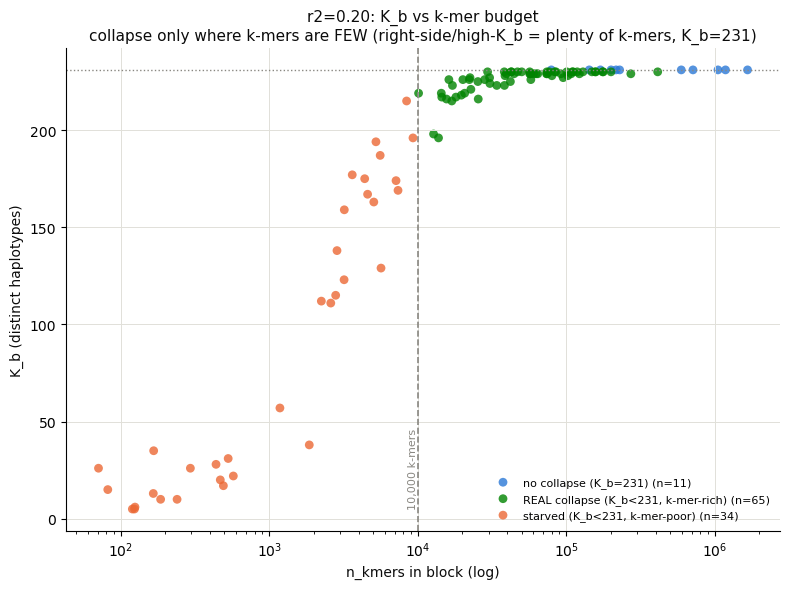

blocks with REAL collapse (K_b<231 AND n_kmers>10,000): 65/110
blocks with K_b<100: 17  of which k-mer-rich (>10,000): 0


In [2]:

# THE KEY DIAGNOSTIC: K_b vs n_kmers. If low-K_b blocks cluster at LOW n_kmers,
# the collapse is starvation. Real IBD collapse would be points that are low-K_b
# AND high-n_kmers (upper-left). Log-x because n_kmers spans 71 -> 1.6M.
fig, ax = plt.subplots(figsize=(8, 6))
for kind, col in [("no collapse (K_b=231)", COLORS["haploblock"]),
                  ("REAL collapse (K_b<231, k-mer-rich)", COLORS["real"]),
                  ("starved (K_b<231, k-mer-poor)", COLORS["starved"])]:
    d = df[df.kind == kind]
    ax.scatter(d.n_kmers, d.K_b, s=40, alpha=0.8, color=col, edgecolor="none",
               label=f"{kind} (n={len(d)})")
ax.axvline(KMER_FLOOR, color=MUTED, lw=1.2, ls="--")
ax.annotate(f"{KMER_FLOOR:,} k-mers", (KMER_FLOOR, df.K_b.min()), color=MUTED, fontsize=8,
            rotation=90, va="bottom", ha="right")
ax.axhline(F, color=MUTED, lw=1, ls=":")
ax.set_xscale("log")
ax.set_xlabel("n_kmers in block (log)", color=INK)
ax.set_ylabel("K_b (distinct haplotypes)", color=INK)
ax.set_title("r2=0.20: K_b vs k-mer budget\n"
             "collapse only where k-mers are FEW (right-side/high-K_b = plenty of k-mers, K_b=231)",
             color=INK, fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.grid(True, color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

nreal = int((df.kind == "REAL collapse (K_b<231, k-mer-rich)").sum())
print(f"blocks with REAL collapse (K_b<231 AND n_kmers>{KMER_FLOOR:,}): {nreal}/{len(df)}")
print(f"blocks with K_b<100: {int((df.K_b<100).sum())}  "
      f"of which k-mer-rich (>{KMER_FLOOR:,}): {int(((df.K_b<100)&(df.n_kmers>KMER_FLOOR)).sum())}")


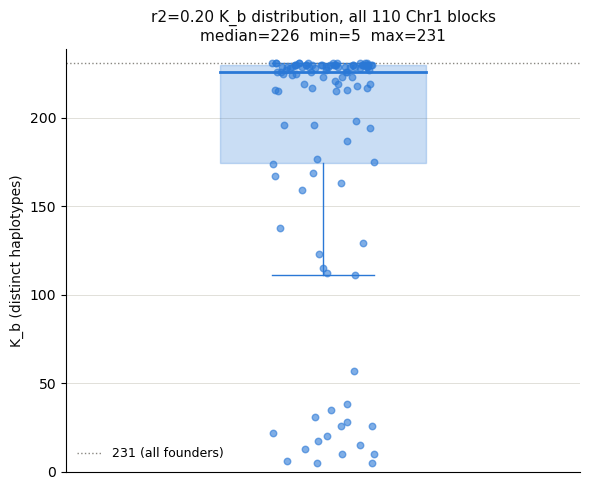

In [3]:

# K_b distribution over all 110 blocks.
fig, ax = plt.subplots(figsize=(6, 5))
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.10, 0.10, size=len(df))
ax.boxplot([df.K_b], positions=[0], widths=0.4, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=COLORS["haploblock"], alpha=0.25, edgecolor=COLORS["haploblock"]),
           medianprops=dict(color=COLORS["haploblock"], lw=2),
           whiskerprops=dict(color=COLORS["haploblock"]), capprops=dict(color=COLORS["haploblock"]))
ax.scatter(jitter, df.K_b, color=COLORS["haploblock"], s=22, alpha=0.6, zorder=3)
ax.axhline(F, color=MUTED, lw=1, ls=":", label="231 (all founders)")
ax.set_xticks([]); ax.set_ylabel("K_b (distinct haplotypes)", color=INK)
ax.set_ylim(0, F + 8)
ax.set_title(f"r2=0.20 K_b distribution, all {len(df)} Chr1 blocks\n"
             f"median={df.K_b.median():.0f}  min={df.K_b.min()}  max={df.K_b.max()}", color=INK, fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, axis="y", color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


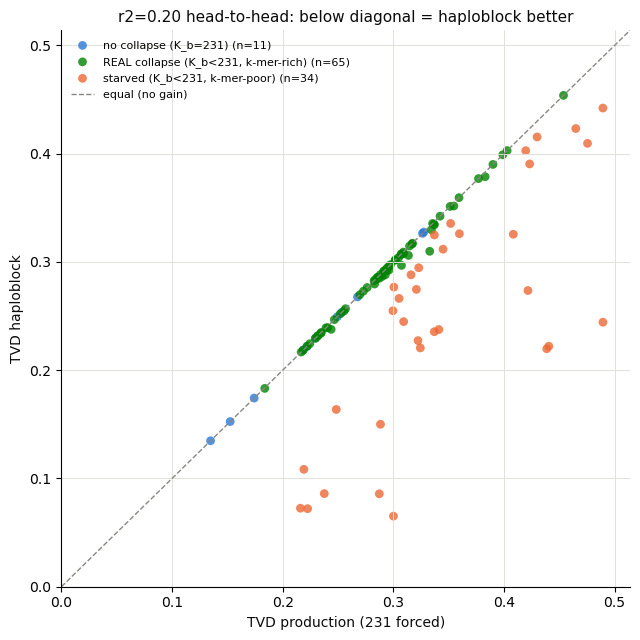

median TVD production = 0.2999
median TVD haploblock = 0.2852
blocks where haploblock strictly better: 86/110  (and where K_b==231, i.e. identical by construction: 11)


In [4]:

# Head-to-head TVD, 110 blocks -> scatter (production x, haploblock y). On the
# diagonal = no difference. Points colored by kind.
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for kind, col in [("no collapse (K_b=231)", COLORS["haploblock"]),
                  ("REAL collapse (K_b<231, k-mer-rich)", COLORS["real"]),
                  ("starved (K_b<231, k-mer-poor)", COLORS["starved"])]:
    d = df[df.kind == kind]
    ax.scatter(d.TVD_production, d.TVD_haploblock, s=40, alpha=0.8, color=col,
               edgecolor="none", label=f"{kind} (n={len(d)})")
lim = [0, max(df.TVD_production.max(), df.TVD_haploblock.max()) * 1.05]
ax.plot(lim, lim, color=MUTED, lw=1, ls="--", label="equal (no gain)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("TVD production (231 forced)", color=INK)
ax.set_ylabel("TVD haploblock", color=INK)
ax.set_title("r2=0.20 head-to-head: below diagonal = haploblock better", color=INK, fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.grid(True, color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"median TVD production = {df.TVD_production.median():.4f}")
print(f"median TVD haploblock = {df.TVD_haploblock.median():.4f}")
better = int((df.TVD_haploblock < df.TVD_production - 1e-9).sum())
print(f"blocks where haploblock strictly better: {better}/{len(df)}  "
      f"(and where K_b==231, i.e. identical by construction: {int((df.K_b==F).sum())})")


## Verdict

Read the K_b-vs-n_kmers diagnostic: if the low-K_b points sit at **low n_kmers**
(orange, left of the k-mer floor) and every k-mer-rich block stays at K_b≈231
(blue, top), then r2=0.20's apparent collapse is **starvation, not real IBD
sharing** — the same failure mode as tiny blocks, just less extreme. In that
case r2=0.20 gives no more real resolution than r2=0.10: the haploblock reframe
still reduces to the 231-forced baseline wherever there are enough k-mers to
trust the estimate.

Real IBD collapse would show as **green** points (K_b well below 231 *with*
many k-mers). Count them: if ~0, the conclusion is that these 231 accessions are
simply too diverse to be k-mer-identical over any region large enough to be
well-powered — so exact-identity haploblocks cannot beat 231 at any starvation-
free block size, and the production choice stays chromosome-wise + Kf_w.
